In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from xgboost import XGBRegressor
import sklearn
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
DATA_PATH = Path(
    "../data/processed/daily_terminal_volume.csv"
)

df_complete = pd.read_csv(
    DATA_PATH,
    parse_dates=["Date"]
)

df_complete = (
    df_complete.sort_values(["location", "Date"])
    .reset_index(drop=True)
)



In [3]:
benchmark_forecasts = pd.read_csv(
    "../outputs/tables/benchmark_holdout_forecasts.csv",
    parse_dates=["Date"]
)

In [4]:
df_complete["holiday_flag"] = (
    df_complete["is_holiday"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["true", "1"])
    .astype("int8")
)

In [5]:
TRAIN_END = pd.Timestamp("2026-03-07")
TEST_START = pd.Timestamp("2026-03-08")
TEST_END = pd.Timestamp("2026-04-04")

In [6]:

training_history = df_complete.loc[
    df_complete["Date"].le(TRAIN_END)
].copy()

holdout_calendar = df_complete.loc[
    df_complete["Date"].between(
        TEST_START,
        TEST_END
    ),
    [
        "Date",
        "location",
        "holiday_flag"
    ]
].copy()

holdout_actuals = df_complete.loc[
    df_complete["Date"].between(
        TEST_START,
        TEST_END
    ),
    [
        "Date",
        "location",
        "model_volume"
    ]
].copy()

In [7]:
#creating features for xgboost
def create_xgboost_features(data):
    feature_data = (
        data.sort_values(["location", "Date"])
        .copy()
    )

    # Calendar features
    feature_data["day_of_week"] = (
        feature_data["Date"].dt.dayofweek
    )
    feature_data["month"] = (
        feature_data["Date"].dt.month
    )
    feature_data["week_of_year"] = (
        feature_data["Date"]
        .dt.isocalendar()
        .week
        .astype(int)
    )
    feature_data["day_of_year"] = (
        feature_data["Date"].dt.dayofyear
    )
    feature_data["is_weekend"] = (
        feature_data["day_of_week"].ge(5)
        .astype("int8")
    )

    # Cyclical calendar features
    feature_data["day_of_year_sin"] = np.sin(
        2 * np.pi *
        feature_data["day_of_year"] / 365.25
    )

    feature_data["day_of_year_cos"] = np.cos(
        2 * np.pi *
        feature_data["day_of_year"] / 365.25
    )

    feature_data["day_of_week_sin"] = np.sin(
        2 * np.pi *
        feature_data["day_of_week"] / 7
    )

    feature_data["day_of_week_cos"] = np.cos(
        2 * np.pi *
        feature_data["day_of_week"] / 7
    )

    volume_group = feature_data.groupby(
        "location"
    )["model_volume"]

    # Lag features
    for lag in [1, 7, 14, 21, 28, 56, 364, 365]:
        feature_data[f"lag_{lag}"] = (
            volume_group.shift(lag)
        )

    # Rolling features use only earlier dates
    feature_data["rolling_mean_7"] = (
        volume_group.transform(
            lambda values:
            values.shift(1)
            .rolling(7, min_periods=7)
            .mean()
        )
    )

    feature_data["rolling_mean_28"] = (
        volume_group.transform(
            lambda values:
            values.shift(1)
            .rolling(28, min_periods=28)
            .mean()
        )
    )

    feature_data["rolling_mean_56"] = (
        volume_group.transform(
            lambda values:
            values.shift(1)
            .rolling(56, min_periods=56)
            .mean()
        )
    )

    feature_data["rolling_median_28"] = (
        volume_group.transform(
            lambda values:
            values.shift(1)
            .rolling(28, min_periods=28)
            .median()
        )
    )

    feature_data["rolling_std_28"] = (
        volume_group.transform(
            lambda values:
            values.shift(1)
            .rolling(28, min_periods=28)
            .std()
        )
    )

    # Same-weekday history
    weekday_group = feature_data.groupby(
        ["location", "day_of_week"]
    )["model_volume"]

    feature_data["same_weekday_mean_4"] = (
        weekday_group.transform(
            lambda values:
            values.shift(1)
            .rolling(4, min_periods=4)
            .mean()
        )
    )

    feature_data["same_weekday_median_4"] = (
        weekday_group.transform(
            lambda values:
            values.shift(1)
            .rolling(4, min_periods=4)
            .median()
        )
    )

    # Historical operating pattern
    feature_data["historical_operating"] = (
        feature_data["model_volume"].gt(0)
        .astype("int8")
    )

    operating_group = feature_data.groupby(
        ["location", "day_of_week"]
    )["historical_operating"]

    feature_data["same_weekday_operation_rate_8"] = (
        operating_group.transform(
            lambda values:
            values.shift(1)
            .rolling(8, min_periods=8)
            .mean()
        )
    )

    # Recent trend features
    feature_data["mean_7_vs_28"] = (
        feature_data["rolling_mean_7"] /
        feature_data["rolling_mean_28"]
        - 1
    )

    feature_data["mean_28_vs_56"] = (
        feature_data["rolling_mean_28"] /
        feature_data["rolling_mean_56"]
        - 1
    )

    return feature_data

In [8]:
xgb_training_data = create_xgboost_features(
    training_history
)

In [9]:
FEATURE_COLUMNS = [
    "location",
    "day_of_week",
    "month",
    "week_of_year",
    "is_weekend",
    "holiday_flag",
    "day_of_year_sin",
    "day_of_year_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_21",
    "lag_28",
    "lag_56",
    "lag_364",
    "lag_365",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_mean_56",
    "rolling_median_28",
    "rolling_std_28",
    "same_weekday_mean_4",
    "same_weekday_median_4",
    "same_weekday_operation_rate_8",
    "mean_7_vs_28",
    "mean_28_vs_56"
]

TARGET_COLUMN = "model_volume"

In [10]:
xgb_training_data = (
    xgb_training_data.dropna(
        subset=FEATURE_COLUMNS + [TARGET_COLUMN]
    )
    .reset_index(drop=True)
)

In [11]:
X_train = xgb_training_data[
    FEATURE_COLUMNS
].copy()

y_train = xgb_training_data[
    TARGET_COLUMN
].copy()

In [12]:
print(f"Training rows: {len(X_train):,}")
print(f"Features: {X_train.shape[1]}")
print(f"Missing feature values: {X_train.isna().sum().sum()}")
print(f"Training period: {xgb_training_data['Date'].min():%Y-%m-%d} "
      f"to {xgb_training_data['Date'].max():%Y-%m-%d}")

Training rows: 12,216
Features: 28
Missing feature values: 0
Training period: 2022-01-01 to 2026-03-07


In [13]:
#encoding categorical columns
CATEGORICAL_COLUMNS = [
    "location",
    "day_of_week"
]

X_train_encoded = pd.get_dummies(
    X_train,
    columns=CATEGORICAL_COLUMNS,
    dtype="int8"
)

ENCODED_FEATURE_COLUMNS = (
    X_train_encoded.columns.tolist()
)

print(f"Encoded features: {len(ENCODED_FEATURE_COLUMNS)}")
print(f"Missing values: {X_train_encoded.isna().sum().sum()}")

Encoded features: 41
Missing values: 0


In [14]:
#creating a validation/tuning window
INTERNAL_VALIDATION_START = (
    TRAIN_END -
    pd.Timedelta(days=55)
)

fit_mask = (
    xgb_training_data["Date"] <
    INTERNAL_VALIDATION_START
)

validation_mask = (
    xgb_training_data["Date"] >=
    INTERNAL_VALIDATION_START
)

In [15]:
X_fit = X_train_encoded.loc[fit_mask]
y_fit = y_train.loc[fit_mask]

X_validation = X_train_encoded.loc[validation_mask]
y_validation = y_train.loc[validation_mask]

print(f"Model-fitting rows: {len(X_fit):,}")
print(f"Validation rows: {len(X_validation):,}")

Model-fitting rows: 11,768
Validation rows: 448


In [16]:
XGB_PARAMS = {
    "objective": "reg:squarederror",
    "eval_metric": "mae",
    "learning_rate": 0.03,
    "max_depth": 6,
    "min_child_weight": 3,
    "subsample": 0.80,
    "colsample_bytree": 0.70,
    "reg_alpha": 0.10,
    "reg_lambda": 2.00,
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1
}

In [17]:
#configuring the model to stop when the error rate has not improved over a few rounds
xgb_tuning_model = XGBRegressor(
    **XGB_PARAMS,
    n_estimators=1500,
    early_stopping_rounds=75
)

xgb_tuning_model.fit(
    X_fit,
    y_fit,
    eval_set=[
        (X_validation, y_validation)
    ],
    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",75
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'mae'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [18]:
best_n_estimators = (
    xgb_tuning_model.best_iteration + 1
)

print(
    "Best number of trees:",
    best_n_estimators
)

print(
    "Best validation score:",
    xgb_tuning_model.best_score
)

Best number of trees: 258
Best validation score: 224.95919939928822


In [19]:
#Refitting the model using all training data
xgb_model = XGBRegressor(
    **XGB_PARAMS,
    n_estimators=best_n_estimators
)

xgb_model.fit(
    X_train_encoded,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'mae'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [20]:
#Recursively predicting the next day forecast. Adding the todays predcited value and forecasting the next day.Creating the featues whe the cureent foracast is known.
recursive_history = training_history[
    [
        "Date",
        "location",
        "model_volume",
        "holiday_flag"
    ]
].copy()

xgb_prediction_frames = []

for forecast_date in sorted(
    holdout_calendar["Date"].unique()
):
    new_rows = (
        holdout_calendar.loc[
            holdout_calendar["Date"].eq(forecast_date)
        ]
        .copy()
    )

    new_rows["model_volume"] = np.nan

    recursive_history = pd.concat(
        [recursive_history, new_rows],
        ignore_index=True
    )

    recursive_features = create_xgboost_features(
        recursive_history
    )

    current_features = (
        recursive_features.loc[
            recursive_features["Date"].eq(forecast_date)
        ]
        .sort_values("location")
        .copy()
    )

    X_current = current_features[
        FEATURE_COLUMNS
    ].copy()

    X_current = pd.get_dummies(
        X_current,
        columns=CATEGORICAL_COLUMNS,
        dtype="int8"
    )

    X_current = X_current.reindex(
        columns=ENCODED_FEATURE_COLUMNS,
        fill_value=0
    )

    if X_current.isna().any().any():
        raise ValueError(
            f"Missing features for {forecast_date}"
        )

    raw_predictions = xgb_model.predict(X_current)
    predictions = np.clip(raw_predictions, 0, None)

    daily_predictions = current_features[
        ["Date", "location"]
    ].copy()

    daily_predictions["xgb_raw_forecast"] = (
        raw_predictions
    )
    daily_predictions["xgb_forecast"] = predictions

    xgb_prediction_frames.append(daily_predictions)

    prediction_map = dict(
        zip(
            daily_predictions["location"],
            daily_predictions["xgb_forecast"]
        )
    )

    current_date_mask = (
        recursive_history["Date"].eq(forecast_date)
    )

    recursive_history.loc[
        current_date_mask,
        "model_volume"
    ] = (
        recursive_history.loc[
            current_date_mask,
            "location"
        ]
        .map(prediction_map)
    )

In [21]:
xgb_forecasts = pd.concat(
    xgb_prediction_frames,
    ignore_index=True
)

xgb_evaluation = (
    holdout_actuals.merge(
        xgb_forecasts,
        on=["Date", "location"],
        how="left",
        validate="one_to_one"
    )
)


In [22]:
def calculate_metrics(
    data,
    forecast_column,
    model_name
):
    results = []

    for location, location_data in data.groupby("location"):
        actual = location_data["model_volume"]
        forecast = location_data[forecast_column]
        error = forecast - actual

        results.append({
            "Model": model_name,
            "location": location,
            "observations": len(location_data),
            "WAPE": error.abs().sum() / actual.sum(),
            "MAE": error.abs().mean(),
            "RMSE": np.sqrt((error ** 2).mean()),
            "Bias": error.sum() / actual.sum()
        })

    return pd.DataFrame(results)

In [23]:
xgb_metrics = calculate_metrics(
    xgb_evaluation,
    "xgb_forecast",
    "XGBoost"
)

xgb_metrics.style.format({
    "observations": "{:.0f}",
    "WAPE": "{:.2%}",
    "MAE": "{:,.0f}",
    "RMSE": "{:,.0f}",
    "Bias": "{:+.2%}"
})

,Model,location,observations,WAPE,MAE,RMSE,Bias
0,XGBoost,1,28,7.05%,109,168,-3.91%
1,XGBoost,2,28,31.05%,83,120,+9.67%
2,XGBoost,3,28,10.99%,222,346,-7.50%
3,XGBoost,4,28,33.42%,121,147,-15.83%
4,XGBoost,5,28,68.36%,21,23,+59.69%
5,XGBoost,6,28,7.09%,239,339,+0.07%
6,XGBoost,7,28,5.47%,173,237,-0.03%
7,XGBoost,8,28,6.13%,300,379,-0.18%


In [24]:
all_forecasts = (
    benchmark_forecasts.merge(
        xgb_forecasts[
            ["Date", "location", "xgb_forecast"]
        ],
        on=["Date", "location"],
        how="left",
        validate="one_to_one"
    )
)

In [25]:
seasonal_metrics = calculate_metrics(
    all_forecasts,
    "seasonal_naive_forecast",
    "Seasonal naïve"
)

holiday_sarima_metrics = calculate_metrics(
    all_forecasts,
    "sarimax_holiday_forecast",
    "Holiday SARIMA"
)

xgb_metrics = calculate_metrics(
    all_forecasts,
    "xgb_forecast",
    "XGBoost"
)

all_model_metrics = pd.concat(
    [
        seasonal_metrics,
        holiday_sarima_metrics,
        xgb_metrics
    ],
    ignore_index=True
)

In [26]:
all_model_metrics.sort_values(
    ["location", "WAPE"]
).style.format({
    "observations": "{:.0f}",
    "WAPE": "{:.2%}",
    "MAE": "{:,.0f}",
    "RMSE": "{:,.0f}",
    "Bias": "{:+.2%}"
})

,Model,location,observations,WAPE,MAE,RMSE,Bias
8,Holiday SARIMA,1,28,6.10%,94,138,+3.91%
16,XGBoost,1,28,7.05%,109,168,-3.91%
0,Seasonal naïve,1,28,11.06%,171,411,+1.96%
17,XGBoost,2,28,31.05%,83,120,+9.67%
9,Holiday SARIMA,2,28,38.41%,103,167,+33.88%
1,Seasonal naïve,2,28,38.71%,103,148,+19.52%
10,Holiday SARIMA,3,28,10.50%,213,294,-1.42%
18,XGBoost,3,28,10.99%,222,346,-7.50%
2,Seasonal naïve,3,28,18.28%,370,728,+2.89%
11,Holiday SARIMA,4,28,24.55%,89,122,-3.22%


Going back to inspect location 5 volumes closely.
Evaluating the model to find tuning opportunities.

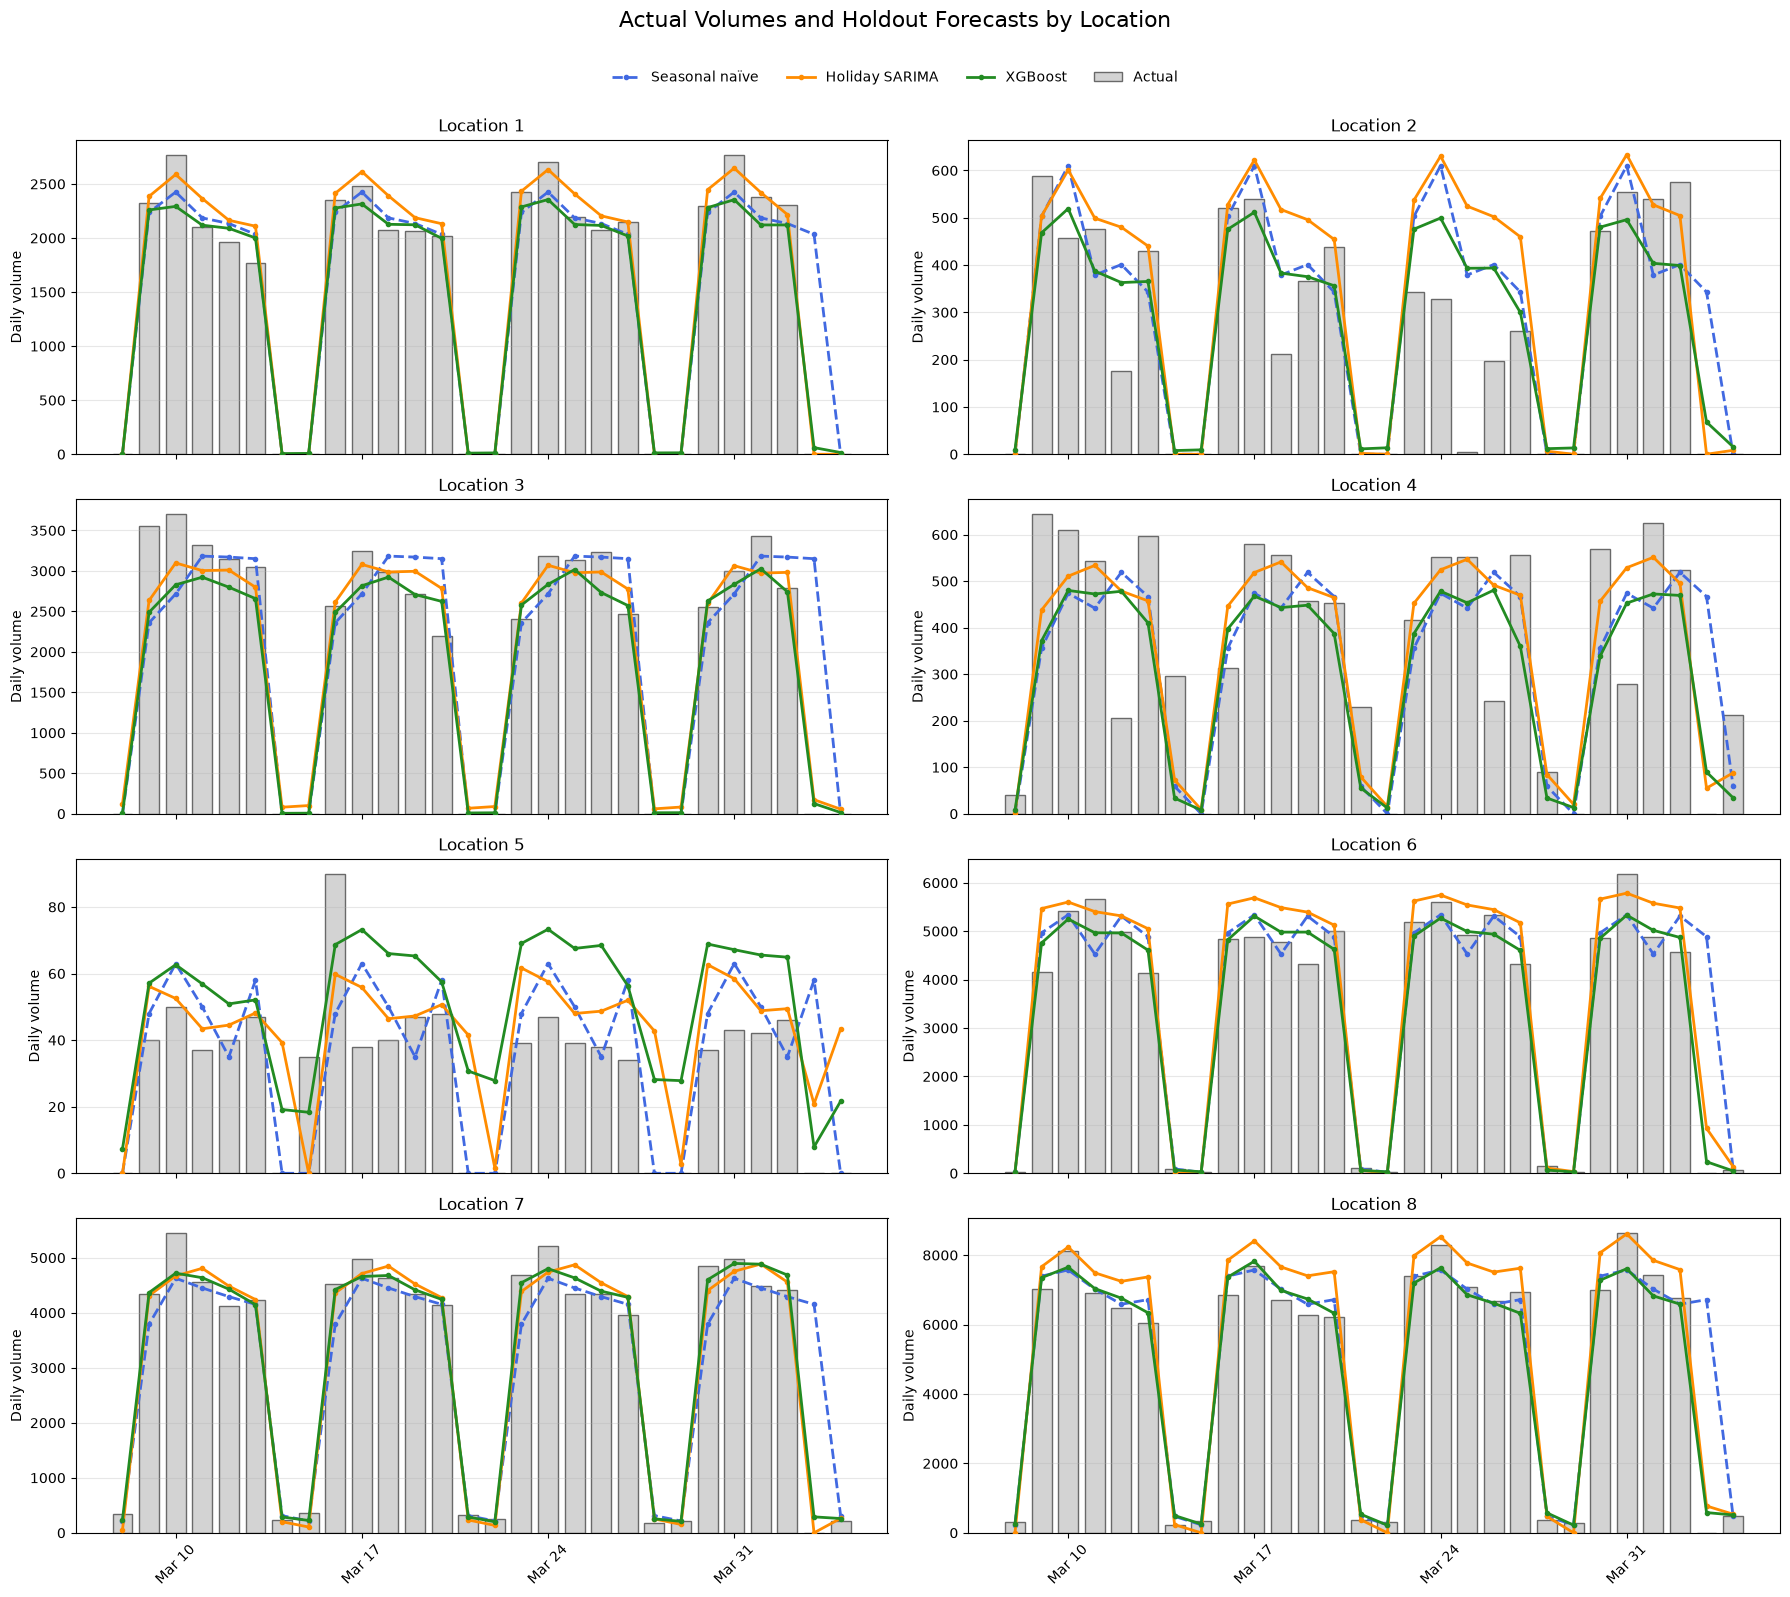

In [27]:
fig, axes = plt.subplots(
    4, 2,
    figsize=(18, 16),
    sharex=True
)

axes = axes.flatten()

for ax, location in zip(
    axes,
    sorted(all_forecasts["location"].unique())
):
    location_data = (
        all_forecasts[
            all_forecasts["location"] == location
        ]
        .sort_values("Date")
    )

    # Actual volumes as bars
    ax.bar(
        location_data["Date"],
        location_data["model_volume"],
        width=0.75,
        color="lightgray",
        edgecolor="dimgray",
        label="Actual",
        zorder=1
    )

    # Forecasts as lines
    ax.plot(
        location_data["Date"],
        location_data["seasonal_naive_forecast"],
        color="royalblue",
        linestyle="--",
        linewidth=2,
        marker="o",
        markersize=3,
        label="Seasonal naïve",
        zorder=2
    )

    ax.plot(
        location_data["Date"],
        location_data["sarimax_holiday_forecast"],
        color="darkorange",
        linewidth=2,
        marker="o",
        markersize=3,
        label="Holiday SARIMA",
        zorder=3
    )

    ax.plot(
        location_data["Date"],
        location_data["xgb_forecast"],
        color="forestgreen",
        linewidth=2,
        marker="o",
        markersize=3,
        label="XGBoost",
        zorder=4
    )

    ax.set_title(f"Location {location}")
    ax.set_ylabel("Daily volume")
    ax.grid(axis="y", alpha=0.3)

    ax.xaxis.set_major_locator(
        mdates.WeekdayLocator(interval=1)
    )
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%b %d")
    )

    ax.tick_params(axis="x", rotation=45)

handles, labels = axes[0].get_legend_handles_labels()

fig.suptitle(
    "Actual Volumes and Holdout Forecasts by Location",
    fontsize=16,
    y=0.995
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=4,
    frameon=False
)


plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(
    "../outputs/figures/validation/Actuals_vs_Forecatsed.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

In [28]:
FORECAST_COLUMN = "xgb_forecast"

xgb_diagnostics = xgb_evaluation.copy()
xgb_diagnostics["Date"] = pd.to_datetime(xgb_diagnostics["Date"])

xgb_diagnostics["error"] = (
    xgb_diagnostics[FORECAST_COLUMN]
    - xgb_diagnostics["model_volume"]
)

xgb_diagnostics["absolute_error"] = xgb_diagnostics["error"].abs()
xgb_diagnostics["squared_error"] = xgb_diagnostics["error"] ** 2
xgb_diagnostics["weekday"] = xgb_diagnostics["Date"].dt.day_name()

xgb_diagnostics["forecast_week"] = (
    (xgb_diagnostics["Date"] - pd.Timestamp(TEST_START)).dt.days // 7
) + 1

In [29]:
def grouped_error_summary(data, group_columns):
    summary = (
        data.groupby(group_columns, as_index=False)
        .agg(
            observations=("model_volume", "size"),
            actual_volume=("model_volume", "sum"),
            absolute_error=("absolute_error", "sum"),
            squared_error=("squared_error", "sum"),
            signed_error=("error", "sum")
        )
    )

    summary["WAPE"] = (
        summary["absolute_error"]
        / summary["actual_volume"]
        * 100
    )

    summary["MAE"] = (
        summary["absolute_error"]
        / summary["observations"]
    )

    summary["RMSE"] = np.sqrt(
        summary["squared_error"]
        / summary["observations"]
    )

    summary["Bias"] = (
        summary["signed_error"]
        / summary["actual_volume"]
        * 100
    )

    return summary

In [30]:
# Does recursive accuracy deteriorate over the four-week horizon?
error_by_terminal_week = grouped_error_summary(
    xgb_diagnostics,
    ["location", "forecast_week"]
)

display(error_by_terminal_week.round(2))

,location,forecast_week,observations,actual_volume,absolute_error,squared_error,signed_error,WAPE,MAE,RMSE,Bias
0,1,1,7,10922.0,937.89,303442.31,-148.18,8.59,133.98,208.20,-1.36
1,1,2,7,10991.0,384.69,38624.22,-134.69,3.50,54.96,74.28,-1.23
2,1,3,7,11554.0,764.04,167797.39,-625.62,6.61,109.15,154.83,-5.41
3,1,4,7,9749.0,962.27,277323.94,-781.08,9.87,137.47,199.04,-8.01
4,2,1,7,2129.0,537.62,65019.94,-8.74,25.25,76.80,96.38,-0.41
5,2,2,7,2078.0,355.43,39122.29,44.61,17.10,50.78,74.76,2.15
6,2,3,7,1135.0,952.57,238177.03,952.57,83.93,136.08,184.46,83.93
7,2,4,7,2141.0,477.53,58415.91,-265.21,22.30,68.22,91.35,-12.39
8,3,1,7,16775.0,3090.99,2323711.40,-3064.02,18.43,441.57,576.16,-18.27
9,3,2,7,13695.0,1012.69,375426.64,-118.75,7.39,144.67,231.59,-0.87


In [31]:
# Which weekdays are difficult for each terminal?
error_by_terminal_weekday = grouped_error_summary(
    xgb_diagnostics,
    ["location", "weekday"]
)

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

error_by_terminal_weekday["weekday"] = pd.Categorical(
    error_by_terminal_weekday["weekday"],
    categories=weekday_order,
    ordered=True
)

display(
    error_by_terminal_weekday
    .sort_values(["location", "weekday"])
    .round(2)
)

,location,weekday,observations,actual_volume,absolute_error,squared_error,signed_error,WAPE,MAE,RMSE,Bias
1,1,Monday,4,9397.0,291.48,28917.11,-291.48,3.10,72.87,85.03,-3.10
5,1,Tuesday,4,10726.0,1408.33,550413.34,-1408.33,13.13,352.08,370.95,-13.13
6,1,Wednesday,4,8750.0,395.78,73238.93,-258.53,4.52,98.94,135.31,-2.95
4,1,Thursday,4,8405.0,414.25,56083.75,44.07,4.93,103.56,118.41,0.52
0,1,Friday,4,5938.0,454.12,77546.37,139.77,7.65,113.53,139.24,2.35
2,1,Saturday,4,0.0,44.82,553.05,44.82,inf,11.20,11.76,inf
3,1,Sunday,4,0.0,40.10,435.31,40.10,inf,10.03,10.43,inf
8,2,Monday,4,1924.0,306.25,34057.13,-24.18,15.92,76.56,92.27,-1.26
12,2,Tuesday,4,1881.0,318.18,36979.92,145.36,16.92,79.55,96.15,7.73
13,2,Wednesday,4,1232.0,785.23,207205.15,335.23,63.74,196.31,227.60,27.21


In [32]:
feature_importance = (
    pd.DataFrame({
        "feature": ENCODED_FEATURE_COLUMNS,
        "importance": xgb_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(20))

,feature,importance
0,same_weekday_mean_4,0.450408
1,same_weekday_median_4,0.186024
2,lag_364,0.132459
3,lag_7,0.042039
4,rolling_mean_7,0.039914
5,lag_14,0.025285
6,holiday_flag,0.024361
7,is_weekend,0.011517
8,rolling_mean_28,0.010993
9,lag_1,0.008236


The model relies heavily on recent same-weekday history.
Errors vary by terminal and weekday.
Tuesdays are difficult for several high-volume terminals.
Locations 4 and 5 have systematic bias.
Weekend errors often come from predicting small positive volumes on actual closure days.

Comparing the actual vs the best forecast values

In [33]:
best_model_by_location = {
    1: "Holiday SARIMA",
    2: "XGBoost",
    3: "Holiday SARIMA",
    4: "Holiday SARIMA",
    5: "Seasonal naïve",
    6: "XGBoost",
    7: "XGBoost",
    8: "XGBoost"
}

forecast_column_by_model = {
    "Holiday SARIMA": "sarimax_holiday_forecast",
    "Seasonal naïve": "seasonal_naive_forecast",
    "XGBoost": "xgb_forecast"
}

best_forecast_table = all_forecasts.copy()

best_forecast_table["selected_model"] = (
    best_forecast_table["location"]
    .map(best_model_by_location)
)

best_forecast_table["best_forecast"] = np.nan

for model_name, forecast_column in forecast_column_by_model.items():
    model_mask = (
        best_forecast_table["selected_model"] == model_name
    )

    best_forecast_table.loc[
        model_mask, "best_forecast"
    ] = best_forecast_table.loc[
        model_mask, forecast_column
    ]

best_forecast_table["forecast_error"] = (
    best_forecast_table["best_forecast"]
    - best_forecast_table["model_volume"]
)

best_forecast_table["absolute_error"] = (
    best_forecast_table["forecast_error"].abs()
)

best_forecast_table = (
    best_forecast_table[
        [
            "Date",
            "location",
            "model_volume",
            "best_forecast",
            "selected_model",
            "forecast_error",
            "absolute_error"
        ]
    ]
    .rename(columns={
        "model_volume": "actual_volume"
    })
    .sort_values(["location", "Date"])
    .reset_index(drop=True)
)

display(
    best_forecast_table.round({
        "actual_volume": 0,
        "best_forecast": 0,
        "forecast_error": 0,
        "absolute_error": 0
    })
)

,Date,location,actual_volume,best_forecast,selected_model,forecast_error,absolute_error
0,2026-03-08,1,0.0,0.0,Holiday SARIMA,0.0,0.0
1,2026-03-09,1,2327.0,2385.0,Holiday SARIMA,58.0,58.0
2,2026-03-10,1,2768.0,2588.0,Holiday SARIMA,-180.0,180.0
3,2026-03-11,1,2102.0,2365.0,Holiday SARIMA,263.0,263.0
4,2026-03-12,1,1960.0,2164.0,Holiday SARIMA,204.0,204.0
...,...,...,...,...,...,...,...
219,2026-03-31,8,8632.0,7609.0,XGBoost,-1023.0,1023.0
220,2026-04-01,8,7424.0,6826.0,XGBoost,-598.0,598.0
221,2026-04-02,8,6776.0,6589.0,XGBoost,-187.0,187.0
222,2026-04-03,8,0.0,583.0,XGBoost,583.0,583.0


In [34]:
best_model_summary = (
    best_forecast_table.groupby(
        ["location", "selected_model"],
        as_index=False
    )
    .agg(
        observations=("actual_volume", "size"),
        total_actual_volume=("actual_volume", "sum"),
        total_predicted_volume=("best_forecast", "sum"),
        absolute_error=("absolute_error", "sum"),
        signed_error=("forecast_error", "sum")
    )
)

best_model_summary["WAPE"] = (
    best_model_summary["absolute_error"]
    / best_model_summary["total_actual_volume"]
    * 100
)

best_model_summary["Bias"] = (
    best_model_summary["signed_error"]
    / best_model_summary["total_actual_volume"]
    * 100
)

display(best_model_summary.round(2))

,location,selected_model,observations,total_actual_volume,total_predicted_volume,absolute_error,signed_error,WAPE,Bias
0,1,Holiday SARIMA,28,43216.0,44907.63,2636.04,1691.63,6.10,3.91
1,2,XGBoost,28,7483.0,8206.24,2323.16,723.24,31.05,9.67
2,3,Holiday SARIMA,28,56682.0,55879.16,5952.82,-802.84,10.50,-1.42
3,4,Holiday SARIMA,28,10145.0,9817.97,2490.75,-327.03,24.55,-3.22
4,5,Seasonal naïve,28,877.0,1016.00,355.00,139.00,40.48,15.85
5,6,XGBoost,28,94574.0,94640.01,6702.88,66.01,7.09,0.07
6,7,XGBoost,28,88720.0,88690.51,4852.31,-29.49,5.47,-0.03
7,8,XGBoost,28,137212.0,136964.65,8412.40,-247.35,6.13,-0.18


In [35]:
from pathlib import Path

OUTPUT_DIRECTORY = Path("../outputs/forecasts")

best_forecast_table.to_csv(
    OUTPUT_DIRECTORY / "best_model_daily_forecasts.csv",
    index=False
)

best_model_summary.to_csv(
    OUTPUT_DIRECTORY / "best_model_location_summary.csv",
    index=False
)

print("Saved:")
print(OUTPUT_DIRECTORY / "best_model_daily_forecasts.csv")
print(OUTPUT_DIRECTORY / "best_model_location_summary.csv")

Saved:
..\outputs\forecasts\best_model_daily_forecasts.csv
..\outputs\forecasts\best_model_location_summary.csv
